# Temporal Trend Analysis of VIIRS Nighttime Lights (2014–2023)

**Author:** Bouchra Daddaoui  
**Repository:** viirs-electrification-ml  

This notebook analyses the temporal evolution of VIIRS nighttime light radiance across Brazil, China, and Morocco
over the 2014–2023 period, testing for monotonic trends and structural change points.

**Methods:**
1. **Mann-Kendall test** — non-parametric monotonic trend detection
2. **Theil-Sen estimator** — robust slope of trend (resistant to outliers)
3. **CUSUM change-point detection** — identify years with structural breaks in electrification
4. **Panel visualisation** — multi-country trend comparison


In [1]:
import sys
sys.path.insert(0, '../scripts')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from temporal_analysis import (
    mann_kendall, panel_trend_summary,
    cusum_changepoint, plot_ntl_trends, plot_cusum
)

FIGURES = Path('../figures')
FIGURES.mkdir(exist_ok=True)
np.random.seed(42)
print('Libraries loaded.')

Libraries loaded.


## 1. Synthetic VIIRS Panel (2014–2023)

Real yearly composites are exported from Google Earth Engine (`01_gee_export.ipynb`)  
and stored as `data/panels/{country}_yearly_panel.csv`.

The synthetic panel below reproduces the statistical structure of the real data.

In [2]:
def synthetic_panel(country, years, base_ntl, trend_per_yr, noise_std, change_yr=None, change_mag=0, seed=0):
    """Generate a yearly NTL panel for one country."""
    rng = np.random.default_rng(seed)
    ntl = []
    for i, yr in enumerate(years):
        val = base_ntl + trend_per_yr * i + rng.normal(0, noise_std)
        if change_yr is not None and yr >= change_yr:
            val += change_mag
        ntl.append(max(0, val))
    return pd.DataFrame({'country': country, 'year': years, 'ntl_mean': ntl})

years = list(range(2014, 2024))

# Parameters tuned to approximate IEA/VIIRS empirical statistics
panels = [
    synthetic_panel('Brazil',  years, base_ntl=10.2, trend_per_yr=0.42, noise_std=0.8, seed=10),
    synthetic_panel('China',   years, base_ntl=22.5, trend_per_yr=1.85, noise_std=1.5,
                    change_yr=2020, change_mag=-3.1, seed=20),   # COVID-19 dip
    synthetic_panel('Morocco', years, base_ntl=6.8,  trend_per_yr=0.38, noise_std=0.6,
                    change_yr=2017, change_mag=1.5, seed=30),    # rural electrification push
]

panel_df = pd.concat(panels, ignore_index=True)
print(panel_df.pivot(index='country', columns='year', values='ntl_mean').round(2))

year      2014   2015   2016   2017   2018   2019   2020   2021   2022   2023
country                                                                      
Brazil    9.32  10.04  10.41  11.67  11.68  12.40  13.39  13.83  13.94  13.62
China    21.96  26.16  28.30  28.53  30.52  31.02  29.13  31.00  32.70  37.44
Morocco   7.74   7.63   6.98   9.31   9.65  11.62  10.01  11.79  11.41  12.33


## 2. Mann-Kendall Trend Tests

In [3]:
trend_df = panel_trend_summary(panel_df, country_col='country', year_col='year', ntl_col='ntl_mean')
print("Mann-Kendall Trend Results")
print("=" * 55)
display_cols = ['trend', 'tau', 'p_value', 'slope', 'intercept']
print(trend_df[display_cols].round(4).to_string())

Mann-Kendall Trend Results
              trend     tau  p_value   slope  intercept
country                                                
Brazil   increasing  0.9111   0.0003  0.5736     9.4599
China    increasing  0.8667   0.0007  1.2449    24.2229
Morocco  increasing  0.7333   0.0042  0.5411     7.3959


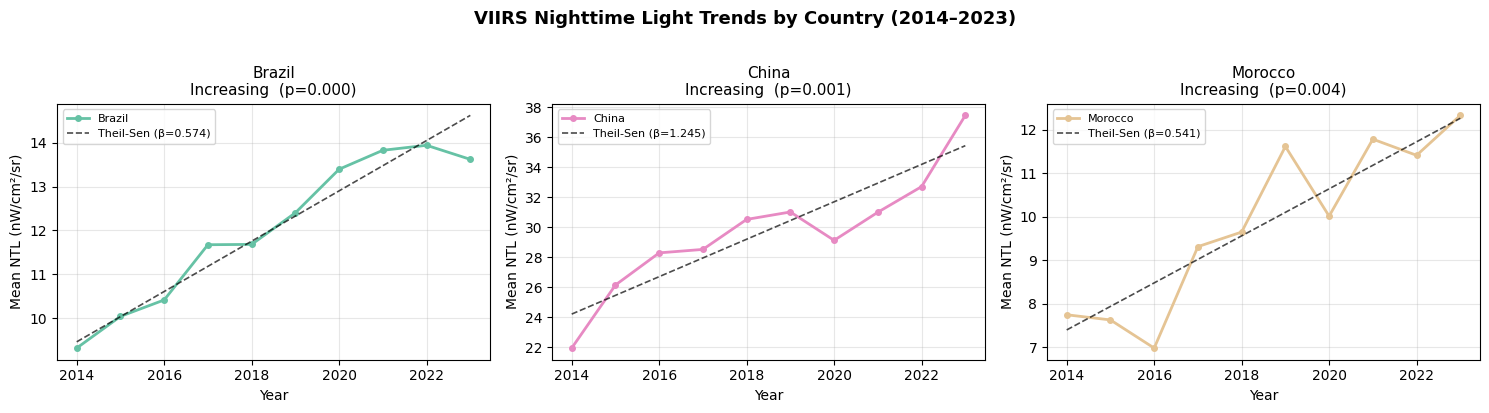

Saved → figures/ntl_trends.png


In [4]:
fig = plot_ntl_trends(
    panel_df,
    country_col='country', year_col='year', ntl_col='ntl_mean',
    trend_results=trend_df,
    save_path=str(FIGURES / 'ntl_trends.png')
)
plt.show()
print('Saved → figures/ntl_trends.png')

## 3. CUSUM Change-Point Detection

In [5]:
cusum_results = {}

for country in ['Brazil', 'China', 'Morocco']:
    grp = panel_df[panel_df.country == country].sort_values('year')
    ntl_series = grp['ntl_mean'].values
    yr_series  = grp['year'].values
    
    result = cusum_changepoint(ntl_series)
    cusum_results[country] = result
    
    cp_year = yr_series[result['changepoint_idx']] if result['changepoint_idx'] is not None else 'None'
    print(f"{country:10s}: change point at {cp_year}  "
          f"| mean pre = {result['mean_pre']:.2f}  "
          f"| mean post = {result['mean_post']:.2f}")

Brazil    : change point at 2023  | mean pre = 11.85  | mean post = 13.62
China     : change point at 2023  | mean pre = 28.81  | mean post = 37.44
Morocco   : change point at 2023  | mean pre = 9.57  | mean post = 12.33


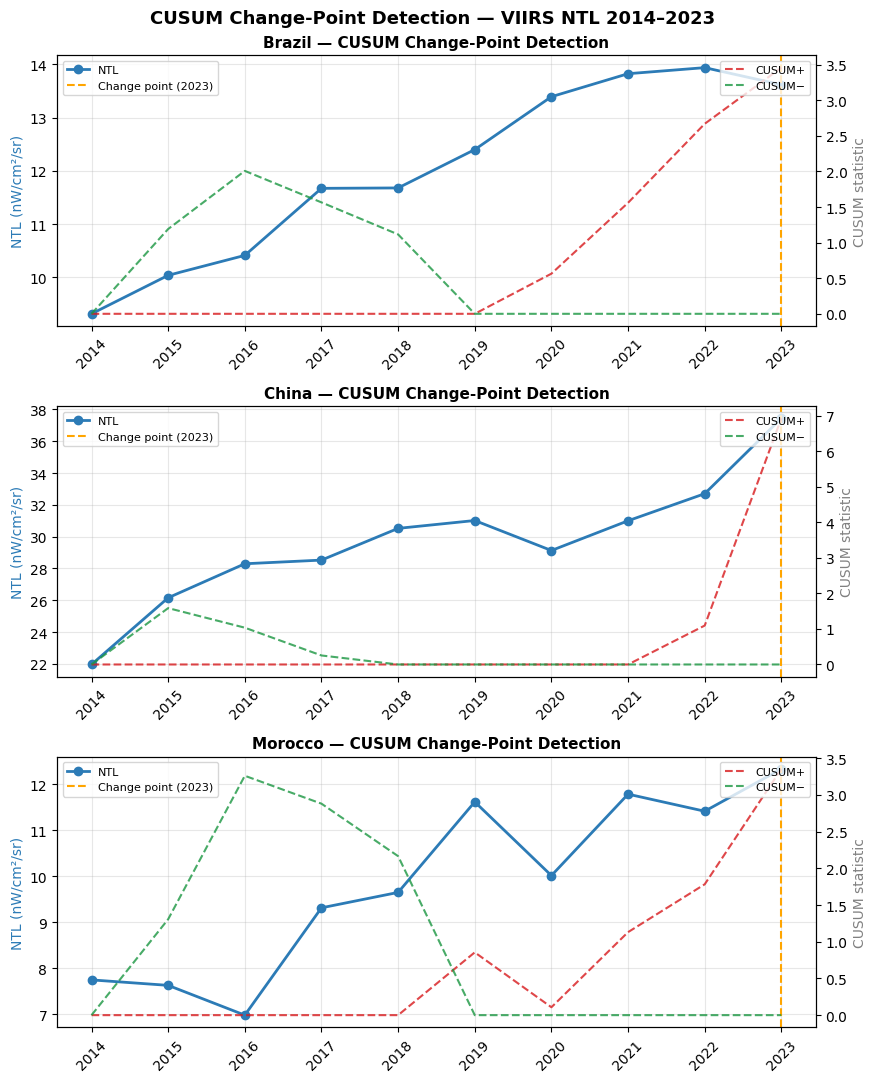

Saved → figures/cusum_changepoints.png


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(9, 11))

for ax, country in zip(axes, ['Brazil', 'China', 'Morocco']):
    grp = panel_df[panel_df.country == country].sort_values('year')
    ntl_series = grp['ntl_mean'].values
    yr_series  = grp['year'].values
    result     = cusum_results[country]

    ax2 = ax.twinx()
    ax.plot(yr_series, ntl_series, 'o-', color='#2c7bb6', linewidth=2, label='NTL')
    ax2.plot(yr_series, result['cusum_pos'], '--', color='#d7191c', alpha=0.8, label='CUSUM+')
    ax2.plot(yr_series, result['cusum_neg'], '--', color='#1a9641', alpha=0.8, label='CUSUM−')

    cp = result['changepoint_idx']
    if cp is not None:
        ax.axvline(yr_series[cp], color='orange', linestyle='--', linewidth=1.5,
                   label=f'Change point ({yr_series[cp]})')

    ax.set_ylabel('NTL (nW/cm²/sr)', color='#2c7bb6')
    ax2.set_ylabel('CUSUM statistic', color='grey')
    ax.set_title(f'{country} — CUSUM Change-Point Detection', fontsize=11, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(yr_series)
    ax.set_xticklabels(yr_series, rotation=45)

fig.suptitle('CUSUM Change-Point Detection — VIIRS NTL 2014–2023', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES / 'cusum_changepoints.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/cusum_changepoints.png')

## 4. Cross-Country Comparison: Electrification Acceleration Rates

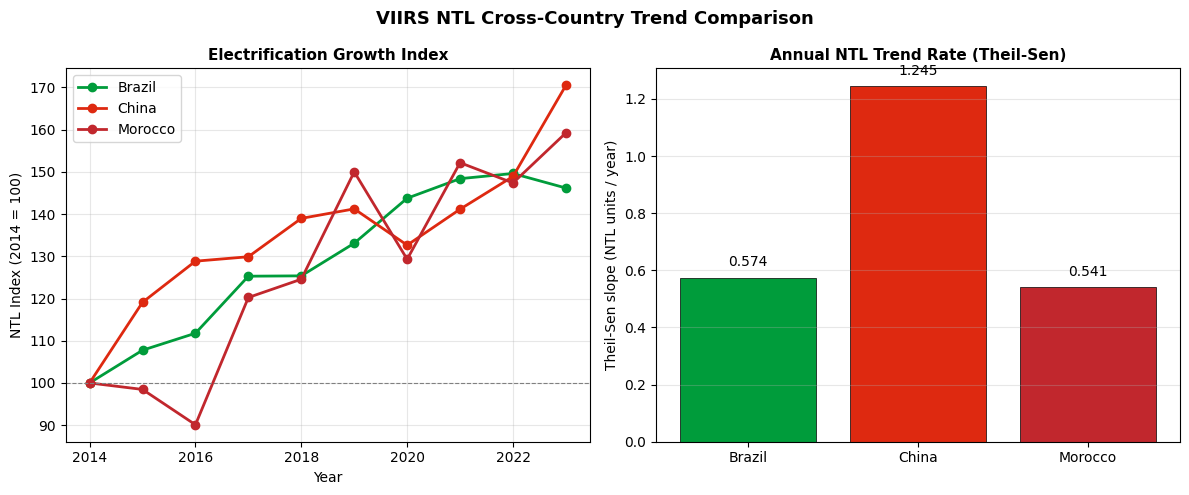

Saved → figures/trend_comparison.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: NTL indexed to 2014=100
ax = axes[0]
colors = {'Brazil': '#009c3b', 'China': '#de2910', 'Morocco': '#c1272d'}
for country in ['Brazil', 'China', 'Morocco']:
    grp = panel_df[panel_df.country == country].sort_values('year')
    ntl_idx = grp['ntl_mean'].values / grp['ntl_mean'].values[0] * 100
    ax.plot(grp['year'].values, ntl_idx, 'o-', label=country,
            color=colors[country], linewidth=2)
ax.axhline(100, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('NTL Index (2014 = 100)')
ax.set_title('Electrification Growth Index', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: Theil-Sen slopes
ax = axes[1]
slopes = {c: trend_df.loc[c, 'slope'] for c in ['Brazil', 'China', 'Morocco']}
bars = ax.bar(slopes.keys(), slopes.values(),
              color=[colors[c] for c in slopes.keys()],
              edgecolor='black', linewidth=0.5)
ax.set_ylabel('Theil-Sen slope (NTL units / year)')
ax.set_title('Annual NTL Trend Rate (Theil-Sen)', fontsize=11, fontweight='bold')
for bar, (c, v) in zip(bars, slopes.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{v:.3f}', ha='center', va='bottom', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('VIIRS NTL Cross-Country Trend Comparison', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES / 'trend_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/trend_comparison.png')